### Importing necessary libraries and handling warnings

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from spextractor import Spextractor
import warnings

warnings.filterwarnings("ignore")

In [3]:
input_folder = 'sample_data'
output_folder = 'processed_sample'
os.makedirs(output_folder, exist_ok=True)

json_files = [f for f in os.listdir(input_folder) if f.endswith('.json')]
print(f"Found {len(json_files)} JSON files to process...")

all_results = []
features_to_measure = ('Si II 6150A', 'Si II 5800A')

for filename in json_files:
    print(f"Processing: {filename} ...")
    
    file_path = os.path.join(input_folder, filename)
    
    try:
        with open(file_path, 'r') as f:
            data_json = json.load(f)
        
        sn_name = list(data_json.keys())[0]
        try:
            z_str = data_json[sn_name]['redshift'][0]['value']
            z = float(z_str)
        except (KeyError, IndexError):
            print(f"No redshift in {filename}")
            continue

        try:
            raw_data = data_json[sn_name]['spectra'][0]['data']
            data_arr = np.array(raw_data, dtype=float)
        except (KeyError, IndexError, ValueError):
            print(f"Corrupt spectral data in {filename}")
            continue

        rows, cols = data_arr.shape
        wavelength = data_arr[:, 0]
        flux = data_arr[:, 1]
        if cols >= 3:
            error = data_arr[:, 2]
        else:
            error = np.full(rows, 1e-20)

        if np.ndim(error) == 0 or error.size == 1:
            error = np.full(rows, 1e-20)

        error = error.astype(float)
        mask_identical = np.isclose(flux, error)
        mask_zero = (error == 0)
        bad_errors = mask_identical | mask_zero
        if np.any(bad_errors):
            error[bad_errors] = 1e-20
            
        temp_dat_path = os.path.join(output_folder, f"{sn_name}.dat")
        clean_data = np.column_stack((wavelength, flux, error))
        np.savetxt(temp_dat_path, clean_data, fmt='%s')

# RUN ANALYSIS
        spex = Spextractor(temp_dat_path, z=z, plot=False)
        spex.create_model(model_type='SKI')
        spex.process(features_to_measure)
        
        row = {'Filename': filename, 'SN Name': sn_name, 'z': z}
        
        for feat in features_to_measure:
            prefix = feat.replace("Si II ", "")
            
            if feat in spex.vel:
                row[f'{prefix} Vel'] = spex.vel[feat]
                row[f'{prefix} V_Err'] = spex.vel_err[feat]
                row[f'{prefix} pEW'] = spex.pew[feat]
                row[f'{prefix} pEW_Err'] = spex.pew_err[feat]
            else:
                row[f'{prefix} Vel'] = np.nan
                row[f'{prefix} V_Err'] = np.nan
                row[f'{prefix} pEW'] = np.nan
                row[f'{prefix} pEW_Err'] = np.nan

        all_results.append(row)
        print("Done.")

    except Exception as e:
        print(f"   -> ERROR on {filename}: {e}")

print("\n" + "="*50)
print("PROCESSING COMPLETE")
print("="*50)

df = pd.DataFrame(all_results)
print(df)

df.to_csv('sample_data.csv', index=False)
print("\nResults saved to 'sample_data.csv'")

Found 122 JSON files to process...
Processing: SN2000dn.json ...
Done.
Processing: SN2008fr.json ...
Done.
Processing: SN2007ux.json ...
Done.
Processing: SN1999cp.json ...
Done.
Processing: PS1-14ra.json ...
Done.
Processing: SN2005el.json ...
Done.
Processing: SN2008fp.json ...
Done.
Processing: LSQ13ry.json ...
Corrupt spectral data in LSQ13ry.json
Processing: SN2009le.json ...
Done.
Processing: SN2007af.json ...
Done.
Processing: SN2007on.json ...
Done.
Processing: SN2009ds.json ...
Done.
Processing: SN2000cx.json ...
Done.
Processing: SN2012gm.json ...
Done.
Processing: SN2000dr.json ...
Done.
Processing: SN2006hx.json ...
Done.
Processing: LSQ12hzj.json ...
Corrupt spectral data in LSQ12hzj.json
Processing: ASASSN-14my.json ...
Corrupt spectral data in ASASSN-14my.json
Processing: SN2009ad.json ...
Done.
Processing: ASASSN-14hr.json ...
Done.
Processing: SN2002er.json ...


Flux array is too large (>4000). Downsampling will be adjusted. 


Done.
Processing: SN2014I.json ...
Done.
Processing: SN2007le.json ...
Done.
Processing: SN2008gl.json ...
Done.
Processing: SN2008gg.json ...
Corrupt spectral data in SN2008gg.json
Processing: SN2012hr.json ...
Done.
Processing: SN2007ol.json ...
Done.
Processing: SN2002dl.json ...
Done.
Processing: LSQ12gdj.json ...
Done.
Processing: ASASSN-15fr.json ...
Done.
Processing: SN2012bl.json ...
Corrupt spectral data in SN2012bl.json
Processing: SN2009ab.json ...
Done.
Processing: SN2008C.json ...
Done.
Processing: SN2003Y.json ...
Done.
Processing: SN2003gt.json ...
Done.
Processing: SN2007bd.json ...
Done.
Processing: SN2001ep.json ...
Done.
Processing: SN2009ag.json ...
Done.
Processing: SN2007ca.json ...
Done.
Processing: SN2006lf.json ...
Done.
Processing: SN2011jh.json ...
Done.
Processing: SN2002ha.json ...
Done.
Processing: SN2008bq.json ...
Done.
Processing: SN2008hj.json ...
Done.
Processing: SN2003gn.json ...
Done.
Processing: SN2008hu.json ...
Done.
Processing: SN2006cp.json ..

Flux array is too large (>4000). Downsampling will be adjusted. 


Done.
Processing: SN2002cr.json ...
Done.
Processing: ASASSN-15hf.json ...
Done.
Processing: SN2001en.json ...
Done.
Processing: SN2002eb.json ...
Done.
Processing: SN2014dn.json ...
Done.
Processing: SN2006D.json ...
Done.
Processing: SN2012ht.json ...
Done.
Processing: ASASSN-14kq.json ...
Done.
Processing: SN2005bg.json ...
Done.
Processing: SN2001V.json ...


...

Done.
Processing: SN2007ba.json ...
Done.
Processing: SN2008O.json ...
Corrupt spectral data in SN2008O.json
Processing: SN2013gy.json ...
Done.
Processing: SN2008fl.json ...
Corrupt spectral data in SN2008fl.json
Processing: SN2006hb.json ...
Done.
Processing: SN2008bf.json ...
Done.
Processing: SN2011iv.json ...


Flux array is too large (>4000). Downsampling will be adjusted. 


Done.
Processing: SN2005cf.json ...
Done.
Processing: SN2008hv.json ...
Done.
Processing: SN2008go.json ...
Corrupt spectral data in SN2008go.json
Processing: SN2008ia.json ...
Done.
Processing: SN1998dh.json ...
Done.
Processing: ASASSN-15be.json ...
Corrupt spectral data in ASASSN-15be.json
Processing: SN2008fw.json ...
Corrupt spectral data in SN2008fw.json
Processing: ASASSN-15al.json ...
Done.
Processing: SN2008bc.json ...
Done.
Processing: SN2013fy.json ...
Done.
Processing: LSQ12fxd.json ...
Done.
Processing: SN2007S.json ...
Done.
Processing: SN2007bm.json ...
Done.
Processing: SN2006ex.json ...
Done.
Processing: SN2005hc.json ...
Done.
Processing: SN2008R.json ...


Flux array is too large (>4000). Downsampling will be adjusted. 


Done.
Processing: SN2003W.json ...
Done.
Processing: SN2009cz.json ...
Done.
Processing: SN2007ci.json ...
Done.
Processing: SN2006gr.json ...
Done.
Processing: ASASSN-14hu.json ...
Done.
Processing: SN2002fk.json ...
Done.
Processing: SN2012aq.json ...
Done.
Processing: SN2009Y.json ...
Done.
Processing: SN1998dm.json ...
Done.

PROCESSING COMPLETE
             Filename      SN Name         z  6150A Vel  6150A V_Err  \
0       SN2000dn.json     SN2000dn  0.032065  11.062714     0.090519   
1       SN2008fr.json     SN2008fr  0.039000        NaN          NaN   
2       SN2007ux.json     SN2007ux  0.030915  10.570404     0.160478   
3       SN1999cp.json     SN1999cp  0.009480  14.563222     0.093540   
4       PS1-14ra.json     PS1-14ra  0.030000  11.990960     0.133358   
..                ...          ...       ...        ...          ...   
101  ASASSN-14hu.json  ASASSN-14hu  0.015000        NaN          NaN   
102     SN2002fk.json     SN2002fk  0.007132   9.775762     0.092390   


### Result Comparison

In [5]:
df_mine = pd.read_csv('sample_data.csv')
df_paper = pd.read_csv('sample_paper_data.csv')

df_mine['match_name'] = df_mine['SN Name'].astype(str).str.lower().str.strip()
df_paper['match_name'] = df_paper['supernova_name'].astype(str).str.lower().str.strip()

merged = pd.merge(df_mine, df_paper, on='match_name', how='inner')

output_df = merged[[
    'SN Name', 
    '6150A Vel',      
    'v_SiII',        
    '5800A pEW',      
    'pEW_SiII_5972'   
]].copy()

output_df.columns = ['SN_Name', 'Measured_Vel_SiII', 'Paper_Vel_SiII', 'Measured_pEW_5800', 'Paper_pEW_5972']

output_df.to_csv('Comparison.csv', index=False)
print("Saved comparison to 'Comparison.csv'")
print(output_df.head())

Saved comparison to 'Comparison.csv'
    SN_Name  Measured_Vel_SiII  Paper_Vel_SiII  Measured_pEW_5800  \
0  SN2000dn          11.062714             9.7          18.097434   
1  SN2008fr                NaN            10.1                NaN   
2  SN2007ux          10.570404            11.1          40.554554   
3  PS1-14ra          11.990960            11.2          33.056297   
4  SN2005el          15.566961            10.9                NaN   

   Paper_pEW_5972  
0            13.3  
1            19.3  
2            54.3  
3            34.2  
4            19.5  


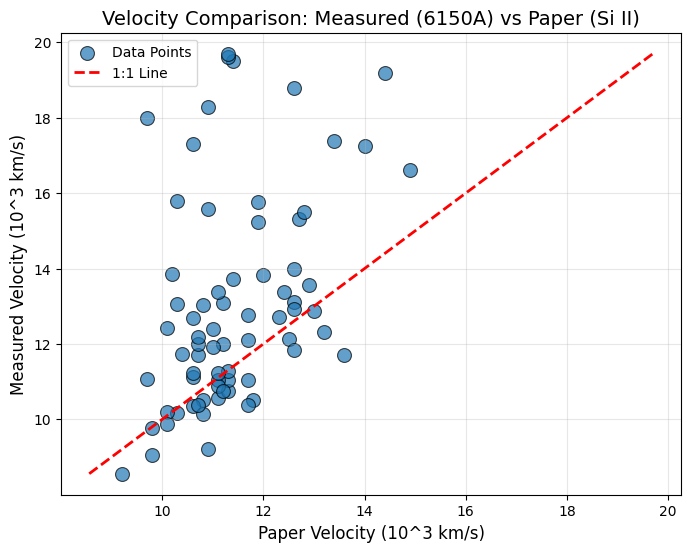

Velocity Mean Absolute Error: 2.00 (10^3 km/s)


In [4]:
df = pd.read_csv('Comparison.csv')

df['Diff_Vel'] = df['Measured_Vel_SiII'] - df['Paper_Vel_SiII']

plt.figure(figsize=(8, 6))
data_v = df.dropna(subset=['Measured_Vel_SiII', 'Paper_Vel_SiII'])

sns.scatterplot(data=data_v, x='Paper_Vel_SiII', y='Measured_Vel_SiII', 
                s=100, alpha=0.7, edgecolor='k', label='Data Points')

min_v = min(data_v['Paper_Vel_SiII'].min(), data_v['Measured_Vel_SiII'].min())
max_v = max(data_v['Paper_Vel_SiII'].max(), data_v['Measured_Vel_SiII'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='1:1 Line')

plt.title('Velocity Comparison: Measured (6150A) vs Paper (Si II)', fontsize=14)
plt.xlabel('Paper Velocity (10^3 km/s)', fontsize=12)
plt.ylabel('Measured Velocity (10^3 km/s)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Velocity Mean Absolute Error: {df['Diff_Vel'].abs().mean():.2f} (10^3 km/s)")

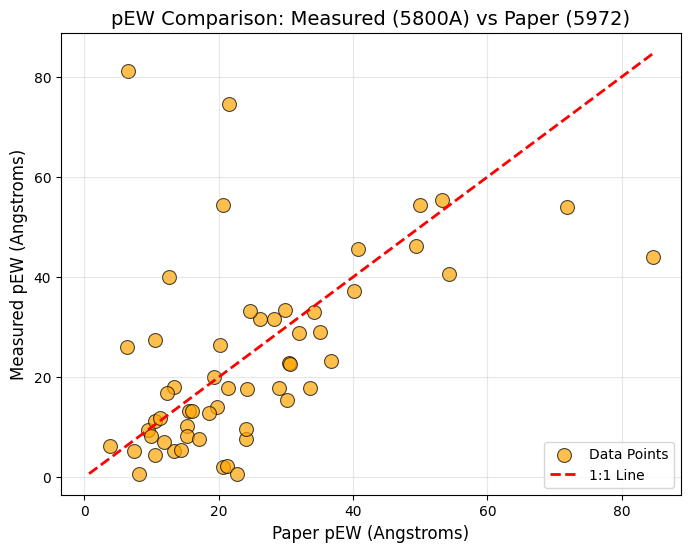

pEW Mean Absolute Error: 10.98 (Angstroms)


In [5]:
df['Diff_pEW'] = df['Measured_pEW_5800'] - df['Paper_pEW_5972']

plt.figure(figsize=(8, 6))
data_p = df.dropna(subset=['Measured_pEW_5800', 'Paper_pEW_5972'])
sns.scatterplot(data=data_p, x='Paper_pEW_5972', y='Measured_pEW_5800', 
                s=100, alpha=0.7, color='orange', edgecolor='k', label='Data Points')

min_p = min(data_p['Paper_pEW_5972'].min(), data_p['Measured_pEW_5800'].min())
max_p = max(data_p['Paper_pEW_5972'].max(), data_p['Measured_pEW_5800'].max())
plt.plot([min_p, max_p], [min_p, max_p], 'r--', lw=2, label='1:1 Line')


plt.title('pEW Comparison: Measured (5800A) vs Paper (5972)', fontsize=14)
plt.xlabel('Paper pEW (Angstroms)', fontsize=12)
plt.ylabel('Measured pEW (Angstroms)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"pEW Mean Absolute Error: {df['Diff_pEW'].abs().mean():.2f} (Angstroms)")